# Reducción del espacio de fase solucion newtoniana

**Fecha:** 2026-06-15


# Simulación Newtoniana

In [3]:
import rebound as rb
import numpy as np
import matplotlib.pyplot as plt

Usamos apenas a y e de s2 dado que este problema tiene simetría esférica

In [4]:
sim = rb.Simulation()
sim.units = ('yr', 'AU', 'Msun')

# Sagitario A*
sim.add(m=1.0)

# S2
sim.add(
    m=1e-6,
    a=25240.143,
    e=0.885
)

Integramos en un periodo, calculado con las leyes de keppler

In [5]:
P = 25240.143**(3/2)
times = np.linspace(-P/4, P/4, 10000)

In [6]:
xyzs = np.zeros((len(times), 3))
vxyzs = np.zeros_like(xyzs)

for i, time in enumerate(times):
    sim.integrate(time)
    S2 = sim.particles[1]
    xyzs[i] = S2.xyz
    vxyzs[i] = S2.vxyz

(np.float64(-40371.05161203072),
 np.float64(4963.242634379298),
 np.float64(-12926.806480694888),
 np.float64(12926.806480694884))

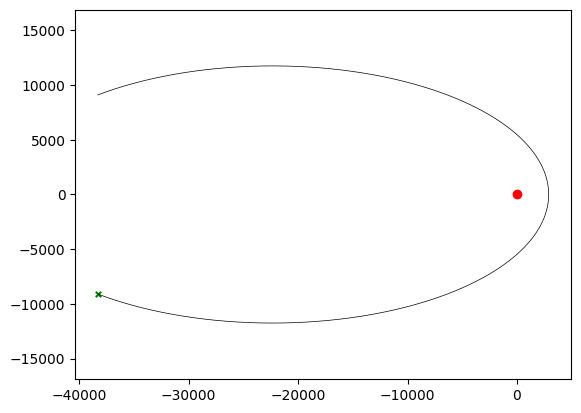

In [7]:
plt.scatter([0],[0], c="r")
plt.scatter(xyzs[0, 0], xyzs[0, 1], c="g", s=15, marker="x")
plt.plot(xyzs[:, 0], xyzs[:, 1], c="k", lw=0.5)

plt.axis("equal")

Tomando el momento angular especifico $\vec{h} = \vec{r} \times \vec{v}$

(array([ 992., 1004., 1014., 1016., 1014., 1000.,  978.,  936.,  888.,
        1158.]),
 array([464.74926268, 464.74965615, 464.75004961, 464.75044308,
        464.75083654, 464.75123001, 464.75162347, 464.75201694,
        464.7524104 , 464.75280387, 464.75319733]),
 <BarContainer object of 10 artists>)

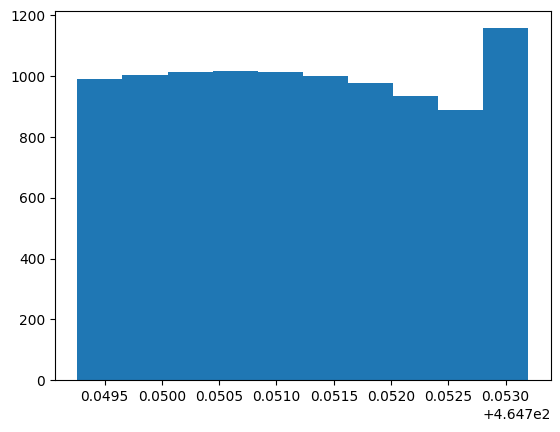

In [8]:
def get_h(xyzs, vxyzs):
    hs = np.zeros_like(xyzs)
    for i, (xyz, vxyzs) in enumerate(zip(xyzs, vxyzs)):
        hs[i] = np.cross(xyz, vxyzs)
    return hs
hs = get_h(xyzs, vxyzs)
hs_norm = np.linalg.norm(hs, axis=1)
h = hs[0]
plt.hist(hs_norm)

# Intento de hallar la distribución

In [105]:
# Datos astrométricos reales de S2 — Gillessen et al. 2017, ApJ 837, 30
# Fuente VizieR J/ApJ/837/30/table5 (25 años monitoreo órbitas del Centro Galáctico).
# Cache CSV local; descarga de VizieR solo si falta o FORCE=True.
# VizieR no entrega error por época -> sigma astrométrica uniforme NACO (0.16 mas).
from pathlib import Path

import numpy as np
import pandas as pd

VIZIER_CATALOG = "J/ApJ/837/30/table5"
CACHE = Path.cwd().parent / "data" / "s2_gillessen2017.csv"
SIGMA_MAS = 0.16  # sigma astrométrica representativa NACO (Gillessen+2017), uniforme
FORCE = False     # True -> fuerza re-descarga

if CACHE.exists() and not FORCE:
    df_s2 = pd.read_csv(CACHE)
else:
    from astroquery.vizier import Vizier

    Vizier.ROW_LIMIT = -1
    t = Vizier.get_catalogs(VIZIER_CATALOG)[0]
    df_s2 = pd.DataFrame({
        "date_yr": np.asarray(t["Date"], dtype=float),          # año decimal
        "ra_mas": np.ma.filled(t["oRA-S2"].astype(float), np.nan),  # offset RA [mas]
        "dec_mas": np.ma.filled(t["oDE-S2"].astype(float), np.nan), # offset DEC [mas]
        "rv_kms": np.ma.filled(t["RV-S2"].astype(float), np.nan),   # vel radial [km/s]
    })
    df_s2 = df_s2[df_s2["ra_mas"].notna() & df_s2["dec_mas"].notna()].reset_index(drop=True)
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    df_s2.to_csv(CACHE, index=False)

# sigma uniforme (VizieR omite error por época)
df_s2["e_ra_mas"] = SIGMA_MAS
df_s2["e_dec_mas"] = SIGMA_MAS
df_s2 = df_s2[["date_yr", "ra_mas", "dec_mas", "e_ra_mas", "e_dec_mas", "rv_kms"]]
df_s2

,date_yr,ra_mas,dec_mas,e_ra_mas,e_dec_mas,rv_kms
0,1992.224,-9.900000,170.199997,0.16,0.16,NaN
1,1994.314,-33.700001,177.500000,0.16,0.16,NaN
2,1995.534,-41.799999,170.300003,0.16,0.16,NaN
3,1996.253,-47.599998,162.199997,0.16,0.16,NaN
4,1996.427,-50.299999,160.199997,0.16,0.16,NaN
...,...,...,...,...,...,...
140,2016.287,-66.000000,70.800003,0.16,0.16,NaN
141,2016.325,-66.000000,69.699997,0.16,0.16,NaN
142,2016.369,-66.199997,68.699997,0.16,0.16,NaN
143,2016.525,-64.400002,62.700001,0.16,0.16,NaN


In [116]:
# === Datos GRAVITY (VLTI) de S2 — ÚNICAMENTE GRAVITY, desde ESO Science Archive ===
#
# AVISO: la astrometría GRAVITY de S2 NO existe como tabla numérica pública
# (CDS/VizieR vacío para A&A 636/L5, 615/L15, 692/A242; las tablas de los papers
# son solo parámetros orbitales y bitácoras de observación). Lo único GRAVITY-only
# descargable son los FITS interferométricos crudos del ESO archive: contienen
# VISIBILIDADES, no posiciones RA/DEC. Pasar de aquí a astrometría (las RA/DEC que
# usa df_s2) requiere el pipeline de reducción GRAVITY — fuera de alcance de este
# notebook. df_s2 (Gillessen+2017, NACO) sigue siendo la única fuente de posiciones.
#
# Program IDs verificados de la tabla "GRAVITY observations" (GRAVITY Collab. 2022,
# A&A 657 L12). Garantizan instrument=GRAVITY + campo del Centro Galáctico.
import pandas as pd
from astroquery.eso import Eso

DEDICATED = ["60.A-9102(A)", "0104.B-0118(A)"]                 # 100% Centro Galáctico
SHARED = ["105.20B2.002", "105.20B2.003",
          "1103.B-0626(C)", "1103.B-0626(E)"]                  # multiprograma -> filtrar
GC_TARGETS = ("IRS16", "SGR", "GC", "S2", "S29", "S38", "S55")
DOWNLOAD = False  # True -> baja los FITS a gravity_s2/ vía ESO dataPortal

eso = Eso()
eso.ROW_LIMIT = -1

_rows = []
for pid in DEDICATED + SHARED:
    t = eso.query_instrument("gravity", column_filters={"prog_id": pid})
    if t is None:
        continue
    df = t.to_pandas()
    df = df[df["DPR.CATG"].str.upper() == "SCIENCE"]
    if pid in SHARED:  # programas compartidos: quedarse con el campo GC
        tgt = df["OBS TARG NAME"].astype(str).str.upper().fillna("")
        df = df[tgt.apply(lambda s: any(k in s for k in GC_TARGETS))]
    _rows.append(df[["OBS START", "Program ID", "DP.ID", "OBS TARG NAME", "DPR.TECH"]])

df_gravity = (
    pd.concat(_rows, ignore_index=True)
    .drop_duplicates("DP.ID")
    .sort_values("OBS START")
    .reset_index(drop=True)
)
print(f"GRAVITY GC science frames: {len(df_gravity)} | programas: {df_gravity['Program ID'].nunique()}")

if DOWNLOAD:
    from pathlib import Path
    import requests

    out = Path("gravity_s2")
    out.mkdir(exist_ok=True)
    for dp_id in df_gravity["DP.ID"]:
        dest = out / f"{dp_id}.fits"
        if dest.exists():
            continue
        r = requests.get(f"https://dataportal.eso.org/dataPortal/file/{dp_id}", timeout=120)
        r.raise_for_status()
        dest.write_bytes(r.content)
        print("Descargado:", dest)

df_gravity

GRAVITY GC science frames: 603 | programas: 6


,OBS START,Program ID,DP.ID,OBS TARG NAME,DPR.TECH
0,2016-02-25T01:47:30,60.A-9102(A),GRAVI.2016-02-25T02:03:49.555,<NA>,"INTERFEROMETRY,WOLLASTON"
1,2016-02-25T01:47:30,60.A-9102(A),GRAVI.2016-02-25T02:09:33.153,<NA>,"SPECTRUM,WOLLASTON"
2,2016-02-25T02:15:41,60.A-9102(A),GRAVI.2016-02-25T02:16:56.753,<NA>,"INTERFEROMETRY,WOLLASTON"
3,2016-02-25T02:15:41,60.A-9102(A),GRAVI.2016-02-25T02:22:40.351,<NA>,"SPECTRUM,WOLLASTON"
4,2016-02-25T03:13:00,60.A-9102(A),GRAVI.2016-02-25T03:13:21.189,<NA>,"INTERFEROMETRY,WOLLASTON"
...,...,...,...,...,...
598,2021-07-27T09:14:23,1103.B-0626(C),GRAVI.2021-07-27T09:17:35.395,NGC 1365,"SPECTRUM,DIRECT"
599,2021-07-27T09:14:23,1103.B-0626(C),GRAVI.2021-07-27T09:14:35.388,NGC 1365,"INTERFEROMETRY,DIRECT"
600,2021-07-27T09:27:32,1103.B-0626(C),GRAVI.2021-07-27T09:27:44.421,NGC 1365,"INTERFEROMETRY,DIRECT"
601,2021-07-27T09:27:32,1103.B-0626(C),GRAVI.2021-07-27T09:30:50.429,NGC 1365,"SPECTRUM,DIRECT"


(array([ 89.,  89.,   0.,   0.,   0.,   0.,   0.,  30.,   0., 395.]),
 array([16856.07465278, 17054.00704167, 17251.93943056, 17449.87181944,
        17647.80420833, 17845.73659722, 18043.66898611, 18241.601375  ,
        18439.53376389, 18637.46615278, 18835.39854167]),
 <BarContainer object of 10 artists>)

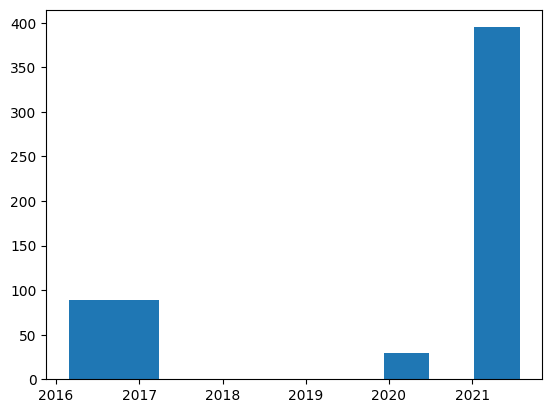

In [135]:

from datetime import datetime

dates = []
for date in df_gravity["OBS START"]:
    dates.append(datetime.fromisoformat(date))

plt.hist(dates,)

# Distribución de puntos uniformemente 

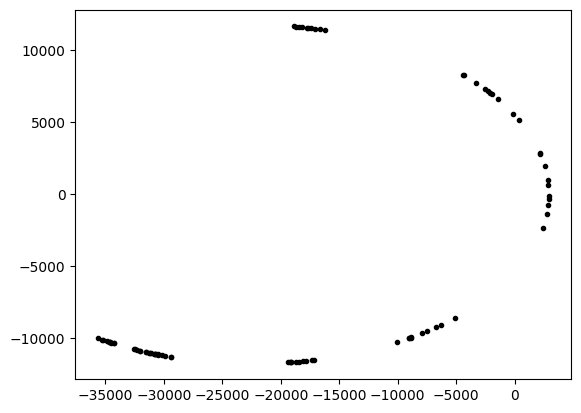

In [9]:
# sample_xyzs = 
np.random.seed(50)
indices_uniform = np.sort(np.random.choice(len(xyzs), size=300, replace=False)).reshape(30,10)
indices_patches = np.sort(np.random.choice(30, size=8, replace=False))
indices = indices_uniform[indices_patches].flatten()

sample_times = times[indices]
sample_xyzs = xyzs[indices]
sample_vxyzs = vxyzs[indices]

plt.plot(sample_xyzs[:,0], sample_xyzs[:, 1], '.k')


Veamos el error

sea $\theta$ el angulo de error en mas. Si suponemos que está a $R_0$:

$\theta[rad] = \theta[mas] / (1000 * 206265)$ 

Así:

$d[pc] = R_0[pc] * \theta[rad]$

Y en unidades feometricas

$d = d[pc] / M_BH[pc]$

$M_{BH}[pc] = 4.785e-14 * M_{BH}[Msun]$


In [10]:
theta_mas = 65e-3 # mas 
theta_rad = theta_mas / (1000 * 206265)
R0 = 8.2e3 # pc
d_pc = R0 * theta_rad

M_BH_pc = 4.785e-14 * 4.26e6

d = d_pc / M_BH_pc
d

12.676814247411313

In [11]:
sample_xyzs_errors = np.ones_like(sample_xyzs)*d
sample_vxyzs_errors = np.ones_like(sample_vxyzs)*d

En velocidades corresponden a 10 km/s, hay que dividir entre la velocidad de la luz

In [12]:
error_vel = 10 / (3e5)
error_vel

3.3333333333333335e-05

In [28]:
class Sample:
    def __init__(self, times, xyzs, vxyzs, N=300, reshape=(30,10), patches=8, seed=50, errors_xyzs=[12.68]*3, errors_vxyzs=[3.3e-5]*3, sample=True) -> None:
        self.original_times = times
        self.original_xyzs = xyzs
        self.original_vxyzs = vxyzs

        if sample:
            np.random.seed(seed)
            indices_uniform = np.sort(np.random.choice(len(xyzs), size=N, replace=False)).reshape(reshape)
            indices_patches = np.sort(np.random.choice(reshape[0], size=patches, replace=False))
            indices = indices_uniform[indices_patches].flatten()
        else:
            indices = np.arange(len(times))

        self.times = times[indices]

        self.xyzs = xyzs[indices]
        self.x = self.xyzs[:, 0]
        self.y = self.xyzs[:, 1]
        self.z = self.xyzs[:, 2]

        self.vxyzs = vxyzs[indices]
        self.vx = self.vxyzs[:, 0]
        self.vy = self.vxyzs[:, 1]
        self.vz = self.vxyzs[:, 2]

        self.errors_x = np.ones(len(self.x))*errors_xyzs[0]
        self.errors_y = np.ones(len(self.x))*errors_xyzs[1]
        self.errors_z = np.ones(len(self.x))*errors_xyzs[2]
        self.errors_xyzs = np.array([self.errors_x, self.errors_y, self.errors_z]).T

        self.errors_vx = np.ones(len(self.x))*errors_vxyzs[0]
        self.errors_vy = np.ones(len(self.x))*errors_vxyzs[1]
        self.errors_vz = np.ones(len(self.x))*errors_vxyzs[2]
        self.errors_vxyzs = np.array([self.errors_vx, self.errors_vy, self.errors_vz]).T

        if sample:
            self.disperse_data(seed)

    def disperse_data(self, seed=40):
        np.random.seed(seed)

        xyzs = np.zeros_like(self.xyzs)
        vxyzs = np.zeros_like(self.xyzs)

        for i, (xyz, vxyz) in enumerate(zip(self.xyzs, self.vxyzs)):
            xyzs[i] = np.random.normal(loc=xyz, scale=self.errors_xyzs[i])
            vxyzs[i] = np.random.normal(loc=vxyz, scale=self.errors_vxyzs[i])

        self.sample = Sample(self.times, xyzs, vxyzs, N=len(self.times), patches=0, seed=seed, errors_xyzs=self.errors_xyzs[0], errors_vxyzs=self.errors_vxyzs[0], sample=False)


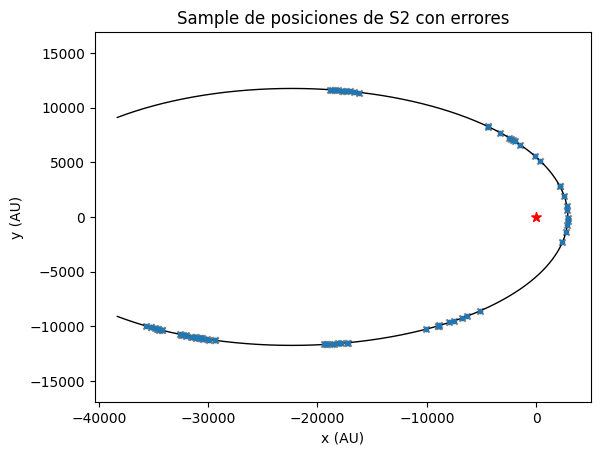

In [40]:
sample_1 = Sample(times, xyzs, vxyzs)

plt.plot(sample_1.original_xyzs[:,0], sample_1.original_xyzs[:, 1], '-k', lw=1, label='Órbita original')

# plot sample_1.sample x, y with error bars
plt.errorbar(
      sample_1.sample.x,
      sample_1.sample.y,
      xerr=sample_1.sample.errors_x,
      yerr=sample_1.sample.errors_y,
      fmt='.',
      ecolor='lightgray',
      elinewidth=0.1,
      capsize=0
  )
plt.scatter(sample_1.sample.x, sample_1.sample.y, c='gray', s=20, marker='x')
plt.scatter(0, 0, c='r', s=50, marker='*')
plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.title('Sample de posiciones de S2 con errores')
plt.axis('equal')
plt.show()

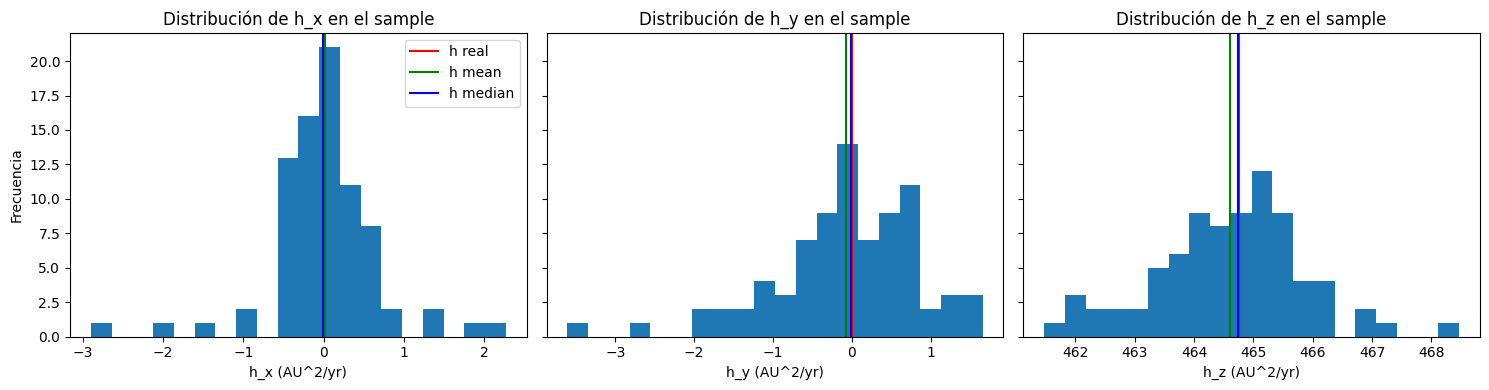

In [51]:
sample_1.hs = get_h(sample_1.sample.xyzs, sample_1.sample.vxyzs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
labels = ['h_x', 'h_y', 'h_z']

for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.hist(sample_1.hs[:, i], bins=20)
    ax.axvline(h[i], color='r', label='h real')
    ax.axvline(sample_1.hs[:, i].mean(), color='g', label='h mean')
    ax.axvline(np.median(sample_1.hs[:, i]), color='b', label='h median')
    ax.set_title(f'Distribución de {label} en el sample')
    ax.set_xlabel(f'{label} (AU^2/yr)')

axes[0].set_ylabel('Frecuencia')
axes[0].legend()
plt.tight_layout()
plt.show()

In [ ]:
def plot_h_contours_sigma(h, sigmas, n=300, n_samples=300, span=1.0, cmap="RdBu", seed=0):
    """Igual que plot_h_contours pero con dispersion en h.

    Fondo (color + colorbar) = tercer eje despejado del plano con h medio.
    Contorno negro = plano orbital medio (eje libre = 0).
    Banda azul = rectas free=0 de draws h ~ N(h, sigmas).
    sigmas = (sigma_hx, sigma_hy, sigma_hz).
    """
    h = np.asarray(h, dtype=float)
    sigmas = np.asarray(sigmas, dtype=float)
    hx, hy, hz = h
    rng = np.random.default_rng(seed)
    samples = rng.normal(h, sigmas, size=(n_samples, 3))

    g = np.linspace(-span, span, n)
    a, b = np.meshgrid(g, g)
    t = np.array([-span, span])

    # (eje_a, eje_b, eje_libre, coef_a, coef_b, coef_libre, idx_a, idx_b)
    planes = [
        ("x", "y", "z", hx, hy, hz, 0, 1),
        ("x", "z", "y", hx, hz, hy, 0, 2),
        ("z", "y", "x", hz, hy, hx, 2, 1),
    ]

    def line(A, B):
        if abs(B) >= abs(A):
            return t, -(A / B) * t if B != 0 else np.zeros_like(t)
        return -(B / A) * t if A != 0 else np.zeros_like(t), t

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for axp, (la, lb, lf, A, B, D, ia, ib) in zip(axes, planes):
        free = np.full_like(a, np.nan) if D == 0 else -(A * a + B * b) / D
        cf = axp.contourf(a, b, free, levels=30, cmap=cmap)
        fig.colorbar(cf, ax=axp, label=lf)
        for s in samples:                       # banda sigma
            la_, lb_ = line(s[ia], s[ib])
            axp.plot(la_, lb_, color="C0", lw=0.5, alpha=0.05)
        axp.contour(a, b, free, levels=[0], colors="k", linewidths=1.5)
        axp.set_xlim(-span, span)
        axp.set_ylim(-span, span)
        axp.set_xlabel(la)
        axp.set_ylabel(lb)
        axp.set_title(f"{la}-{lb}   (color = {lf}, plano ± sigma)")
        axp.set_aspect("equal")
    plt.tight_layout()
    return fig


plot_h_contours_sigma(h, sigmas=np.abs(h) * 0.1)
plt.show()

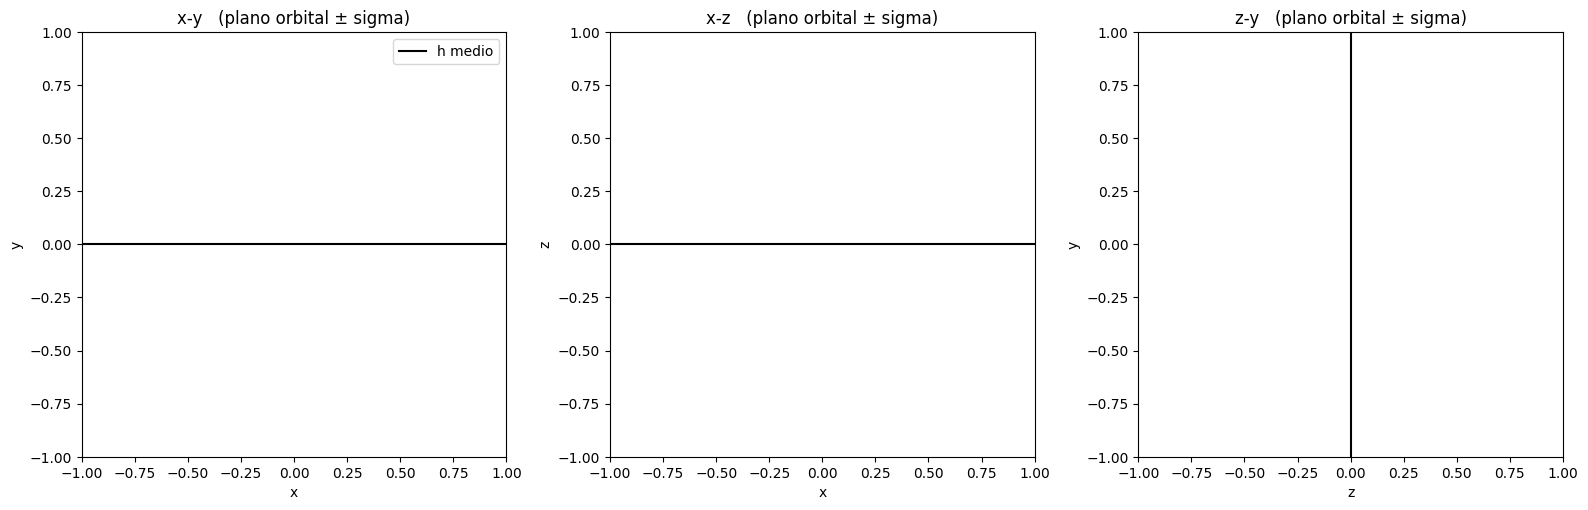

In [26]:
def plot_h_contours_sigma(h, sigmas, n_samples=300, span=1.0, seed=0):
    """Plano orbital h·r = 0 con dispersion en h.

    Proyecciones x-y, x-z, z-y. El plano orbital cae como recta por el origen
    A·a + B·b = 0 (A, B = componentes de h del plano). Se muestrea
    h ~ N(h, sigmas) y se dibuja la recta de cada draw -> banda de incertidumbre.
    sigmas = (sigma_hx, sigma_hy, sigma_hz).
    """
    h = np.asarray(h, dtype=float)
    sigmas = np.asarray(sigmas, dtype=float)
    rng = np.random.default_rng(seed)
    samples = rng.normal(h, sigmas, size=(n_samples, 3))  # (N,3)
    t = np.linspace(-span, span, 2)

    # (eje_a, eje_b, idx_coef_a, idx_coef_b)  recta: A·a + B·b = 0
    planes = [("x", "y", 0, 1), ("x", "z", 0, 2), ("z", "y", 2, 1)]

    def line(A, B):
        # devuelve (a, b) cubriendo la caja segun cual coef domina
        if abs(B) >= abs(A):
            return t, -(A / B) * t if B != 0 else np.zeros_like(t)
        return -(B / A) * t if A != 0 else np.zeros_like(t), t

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for axp, (la, lb, ia, ib) in zip(axes, planes):
        for s in samples:
            a, b = line(s[ia], s[ib])
            axp.plot(a, b, color="C0", lw=0.5, alpha=0.05)
        a, b = line(h[ia], h[ib])  # media
        axp.plot(a, b, "k", lw=1.5, label="h medio")
        axp.set_xlim(-span, span)
        axp.set_ylim(-span, span)
        axp.set_xlabel(la)
        axp.set_ylabel(lb)
        axp.set_title(f"{la}-{lb}   (plano orbital ± sigma)")
        axp.set_aspect("equal")
    axes[0].legend()
    plt.tight_layout()
    return fig


plot_h_contours_sigma(h, sigmas=np.abs(h) * 0.1)
plt.show()